Analiz başlatılıyor... (Makale için ilk 100 kare işleniyor)

--- Kare 0 Teknik Çıktısı ---


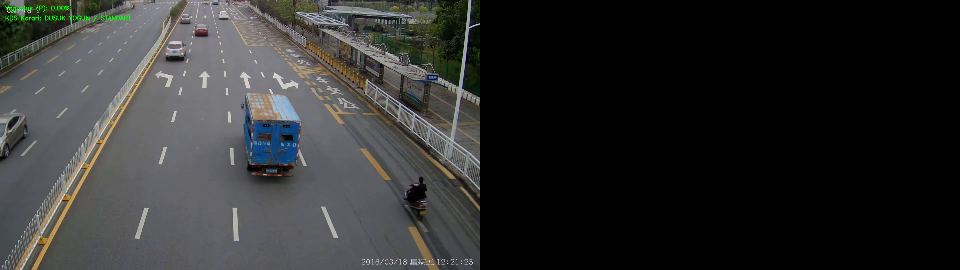


--- Kare 50 Teknik Çıktısı ---


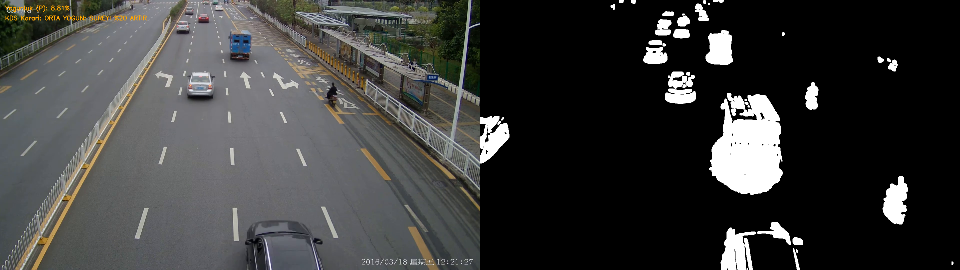


Grafik 'trafik_analiz_sonuc.png' olarak kaydedildi.


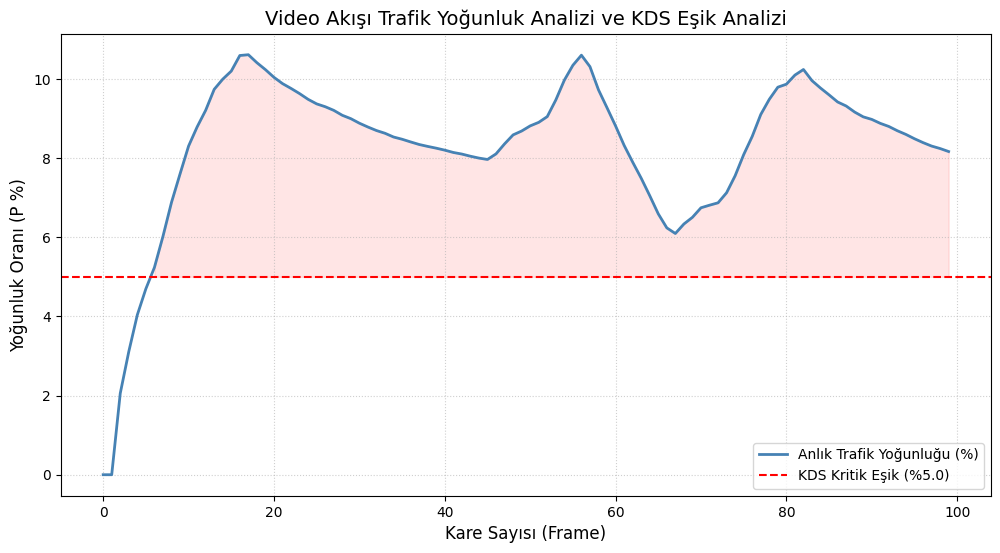

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# 1. ADIM: Video Dosyasını Bağlama
video_path = 'trafik_analizi.mp4'
cap = cv2.VideoCapture(video_path)

ret, first_frame = cap.read()
if not ret:
    print("Video yüklenemedi! Dosya adının 'trafik_analizi.mp4' olduğundan emin olun.")
    exit()

# Arka plan matrisinin (B) hazırlanması
bg_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
bg_gray = cv2.GaussianBlur(bg_gray, (21, 21), 0)

density_list = []
print("Analiz başlatılıyor... (Makale için ilk 100 kare işleniyor)")

frame_count = 0
while frame_count < 100:
    ret, frame = cap.read()
    if not ret: break

    # 2. ADIM: Ön İşleme (Gri Seviye Dönüşümü)
    # Jray = 0.299R + 0.587G + 0.114B (OpenCV bu katsayıları kullanır)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (21, 21), 0)

    # 3. ADIM: Lineer Cebir - Matris Farkı (Segmentasyon)
    # D = |At - B| işlemi [cite: 110, 133]
    frame_delta = cv2.absdiff(bg_gray, gray)

    # Eşikleme (Thresholding) - S İkili Matrisi [cite: 135]
    thresh = cv2.threshold(frame_delta, 25, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.dilate(thresh, None, iterations=2)

    # 4. ADIM: Yoğunluk Analizi (P Oranı)
    # P = (S matrisindeki toplam 1 sayısı) / (m * n) [cite: 151]
    white_pixels = np.count_nonzero(thresh)
    total_pixels = thresh.size
    P = (white_pixels / total_pixels) * 100 # Yüzdelik değer
    density_list.append(P)

    # 5. ADIM: Karar Destek Sistemi (KDS) Mantığı
    if P > 10.0:
        decision = "COK YOGUN: SUREYI %50 ARTIR"
        color = (0, 0, 255) # Kırmızı
    elif 5.0 < P <= 10.0:
        decision = "ORTA YOGUN: SUREYI %20 ARTIR"
        color = (0, 165, 255) # Turuncu
    else:
        decision = "DUSUK YOGUN / STANDART"
        color = (0, 255, 0) # Yeşil

    # Görsel çıktı üzerine verilerin yazılması [cite: 51, 171]
    cv2.putText(frame, f"Yogunluk (P): {P:.2f}%", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.putText(frame, f"KDS Karari: {decision}", (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Her 50 karede bir karşılaştırmalı görsel gösterimi [cite: 168, 172]
    if frame_count % 50 == 0:
        print(f"\n--- Kare {frame_count} Teknik Çıktısı ---")
        combined = np.hstack((cv2.resize(frame, (480, 270)),
                             cv2.resize(cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR), (480, 270))))
        cv2_imshow(combined)

    frame_count += 1

cap.release()

# 6. ADIM: Performans Grafiği Oluşturma [cite: 53, 174, 193]
plt.figure(figsize=(12, 6))
plt.plot(density_list, color='steelblue', linewidth=2, label='Anlık Trafik Yoğunluğu (%)')
plt.axhline(y=5.0, color='red', linestyle='--', label='KDS Kritik Eşik (%5.0)')
plt.fill_between(range(len(density_list)), density_list, 5.0,
                 where=(np.array(density_list) > 5.0), color='red', alpha=0.1)

plt.title('Video Akışı Trafik Yoğunluk Analizi ve KDS Eşik Analizi', fontsize=14)
plt.xlabel('Kare Sayısı (Frame)', fontsize=12)
plt.ylabel('Yoğunluk Oranı (P %)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Grafiği kaydetme ve indirme (Teslim dosyası için) [cite: 66, 67]
plt.savefig('trafik_analiz_sonuc.png', dpi=300)
print("\nGrafik 'trafik_analiz_sonuc.png' olarak kaydedildi.")
# files.download('trafik_analiz_sonuc.png') # İndirmek istersen bu satırı aktif edebilirsin
plt.show()